In [1]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import cutouts_to_patches.cutouts_to_patches as cutouts_to_patches

In [2]:
from nemi import NEMI, SingleNemi

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import torch

In [17]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="1_00",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [ ]:
# cutouts_dataloader = cutouts_dataset.get_cutout_loader(source=source, subset=True, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=1, batch_size=64)
data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']

cutouts_dataloader = cutouts_dataset.get_cutout_loader(data_channels=data_channels, source=source, subset=False, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=1, batch_size=64)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36761 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:34835' processes=1 threads=8, memory=64.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/36761/status


In [35]:
len(cutouts_dataloader) * 64 

3264

In [19]:
patch_size = 8
patched_loader = cutouts_to_patches.PatchedDataLoader(cutouts_dataloader, patch_size=patch_size)
print(len(patched_loader))

patches = torch.cat(
    [patches.reshape(patches.shape[0] * patches.shape[1], -1) for patches in patched_loader], dim=0
).numpy()

print(patches.shape)

51
(208000, 1408)


In [20]:
# Run NEMI on the patches (GPU: cuML UMAP + clustering)
nemi = NEMI(params={
    "device": "gpu",
    "embedding_dict":  {"n_components": 3, "n_neighbors": 200, "min_dist": 0.0},
    "clustering_dict": {"method": "hdbscan", "min_cluster_size": 500, "min_samples": 500},
})

# single member to start; bump n (with assess_overlap=True) for the ensemble
nemi.run(patches, n=1, output="nemi_out.npz")

labels    = nemi.clusters      # (N,) cluster label per patch
embedding = nemi.embedding     # (N, 3) UMAP embedding
print("labels", labels.shape, "| embedding", embedding.shape)

Fitting the embedding
[2026-07-14 18:12:32.512] [CUML] [info] Building knn graph using nn descent
[2026-07-14 18:12:32.513] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-07-14 18:12:32.513] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree.                 setting nnd_intermediate_graph_degree to nnd_graph_degree
[2026-07-14 18:12:41.500] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 500, 'min_samples': 500}
Clusters found: 17
Sorting clusters
labels (208000,) | embedding (208000, 3)


In [30]:
embedding.shape


(208000, 3)

In [27]:
import matplotlib.pyplot as plt
def vis_dim_redux(X_d, labels=None, class_subset=None, label_title="class", dims=2, alpha=0.5):  

    labels = labels

    if dims ==2:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111)

        if labels is not None :
    
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                c=labels,
                cmap="tab10",
                alpha=alpha,
                s=.1
            )

        else :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                alpha=0.1,
                s=.1
            )
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

    if dims == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')

        if labels is not None :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                X_d[:,2],
                c=labels,
                s=.1,
                cmap="tab10",
                alpha=0.1
            )

        else :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                X_d[:,2],
                alpha=0.1,
                s=.1
            )
            
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
        ax.set_zlabel("C3")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

plt.show()

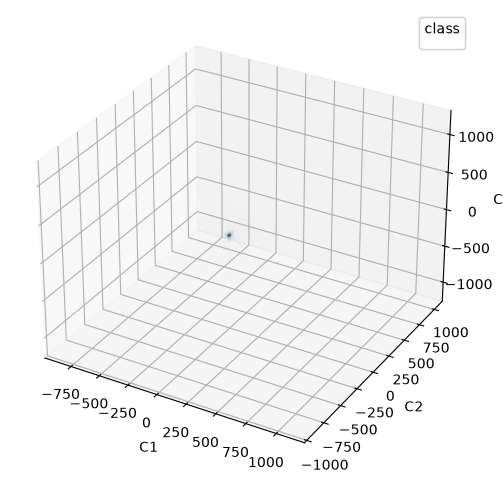

In [28]:
vis_dim_redux(embedding, dims=3)

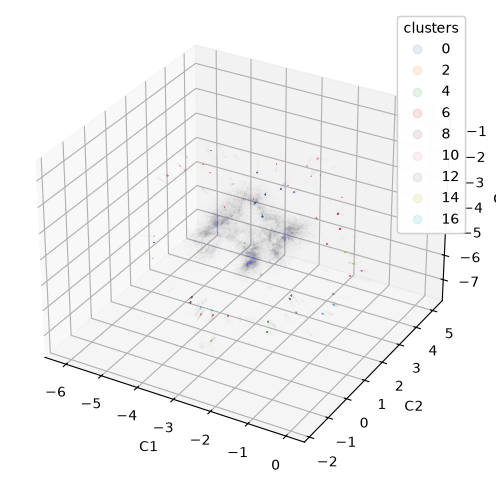

In [29]:
vis_dim_redux(embedding, labels=labels, class_subset=None, label_title="clusters", dims=3)